Epoch 0, Step 0, Loss: 0.4205
Epoch 0, Step 100, Loss: 0.4013
Epoch 0, Step 200, Loss: 0.4056
Epoch 0, Step 300, Loss: 0.4081
Epoch 0, Step 400, Loss: 0.4193
Epoch 1, Step 0, Loss: 0.3817
Epoch 1, Step 100, Loss: 0.4002
Epoch 1, Step 200, Loss: 0.4004
Epoch 1, Step 300, Loss: 0.4093
Epoch 1, Step 400, Loss: 0.3749
Epoch 2, Step 0, Loss: 0.4105
Epoch 2, Step 100, Loss: 0.3840
Epoch 2, Step 200, Loss: 0.4113
Epoch 2, Step 300, Loss: 0.3854
Epoch 2, Step 400, Loss: 0.3731
Epoch 3, Step 0, Loss: 0.3887
Epoch 3, Step 100, Loss: 0.3827
Epoch 3, Step 200, Loss: 0.3785
Epoch 3, Step 300, Loss: 0.3716
Epoch 3, Step 400, Loss: 0.3933
Epoch 4, Step 0, Loss: 0.3884
Epoch 4, Step 100, Loss: 0.3799
Epoch 4, Step 200, Loss: 0.3731
Epoch 4, Step 300, Loss: 0.4066
Epoch 4, Step 400, Loss: 0.3864
Epoch 5, Step 0, Loss: 0.4187
Epoch 5, Step 100, Loss: 0.3679
Epoch 5, Step 200, Loss: 0.3844
Epoch 5, Step 300, Loss: 0.3632
Epoch 5, Step 400, Loss: 0.3598
Epoch 6, Step 0, Loss: 0.3872
Epoch 6, Step 100, Los

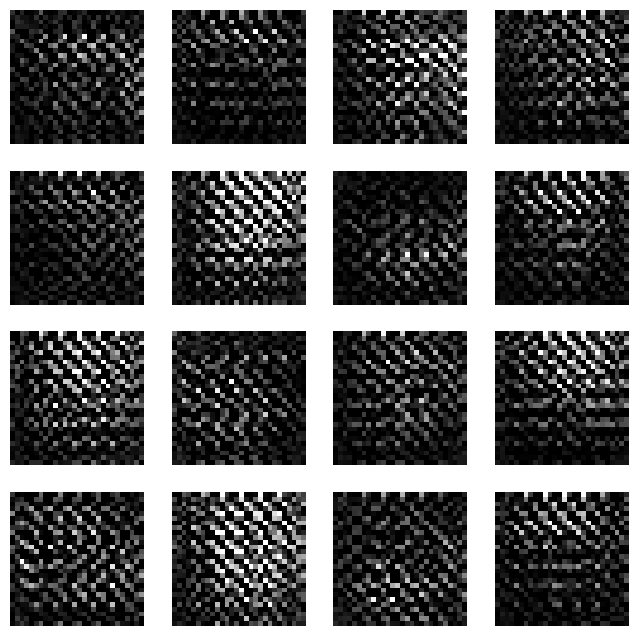

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Parameters
IMG_SIZE = 28
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-4
TIMESTEPS = 1000

# Diffusion Process Helper Functions
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def compute_alpha(beta):
    alpha = 1.0 - beta
    return torch.cumprod(alpha, dim=0)

# Noise Scheduler
betas = linear_beta_schedule(TIMESTEPS)
alphas = compute_alpha(betas)
alphas_prev = torch.cat([torch.tensor([1.0]), alphas[:-1]])

def forward_diffusion(x0, t):
    """Applies forward diffusion to the input x0."""
    noise = torch.randn_like(x0)
    sqrt_alpha_t = torch.sqrt(alphas[t])[:, None, None, None]
    sqrt_one_minus_alpha_t = torch.sqrt(1 - alphas[t])[:, None, None, None]
    return sqrt_alpha_t * x0 + sqrt_one_minus_alpha_t * noise, noise

# U-Net-like Model for Denoising
class SimpleUNet(nn.Module):
    def __init__(self):
        super(SimpleUNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.middle = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 1, kernel_size=2, stride=2)
        )

    def forward(self, x, t):
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        return x

# Dataset and DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

# Training Loop
# model = SimpleUNet()
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

def train():
    model.train()
    for epoch in range(EPOCHS):
        for i, (x, _) in enumerate(train_loader):
            x = x
            t = torch.randint(0, TIMESTEPS, (x.size(0),))
            x_t, noise = forward_diffusion(x, t)

            predicted_noise = model(x_t, t)
            loss = criterion(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if i % 100 == 0:
                print(f"Epoch {epoch}, Step {i}, Loss: {loss.item():.4f}")

# Generate Samples
def sample():
    model.eval()
    with torch.no_grad():
        x = torch.randn((16, 1, IMG_SIZE, IMG_SIZE))
        for t in reversed(range(TIMESTEPS)):
            t_tensor = torch.tensor([t])
            predicted_noise = model(x, t_tensor)

            alpha_t = alphas[t]
            alpha_t_prev = alphas_prev[t]
            beta_t = betas[t]

            sqrt_alpha_t = torch.sqrt(alpha_t)
            sqrt_one_minus_alpha_t = torch.sqrt(1 - alpha_t)

            x = sqrt_alpha_t * x - sqrt_one_minus_alpha_t * predicted_noise

        x = torch.clamp(x, -1.0, 1.0)
        return x

# Train the Model
train()

# Generate and Display Samples
samples = sample().cpu()
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(samples[i, 0], cmap="gray")
    ax.axis("off")
plt.show()
